# code for event segmentation procedure

Adapted from https://github.com/ContextLab/sherlock-topic-model-paper/blob/master/code/notebooks/main/eventseg_analysis.ipynb

### imports

In [1]:
import numpy as np
import pandas as pd
import hypertools as hyp
import brainiak.eventseg.event as event
import pickle
import os
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

### paths

In [2]:
data_dir = '../../data'
ep_traj_dir = f'{data_dir}/models/episodes/trajectories/'
ep_seg_dir = f'{data_dir}/models/episodes/segments/'
ep_emb_dir = f'{data_dir}/models/episodes/embeddings/'
rec_traj_dir = f'{data_dir}/models/participants/trajectories/'
rec_seg_dir = f'{data_dir}/models/participants/segments/'
rec_emb_dir = f'{data_dir}/models/participants/embeddings/'
pickle_dir = '../../data/pickles/'

## load episode trajectories

In [4]:
ep_trajs = {ep: np.load(f'{ep_traj_dir}/{ep}_trajectory.npy') for ep in ['atlep1', 'atlep2', 'arrdev']}

## load participant trajectories

In [7]:
participant_trajs = {rectype : [] for rectype in ['atlep1', 'prediction', 'delayed', 'atlep2', 'arrdev']}
avg_participant_trajs = dict.fromkeys(participant_trajs)

for rectype in participant_trajs.keys():
    rt_dir = os.path.join(rec_traj_dir, rectype)
    for f in os.listdir(rt_dir):
        if f.startswith('debug'):
            participant_trajs[rectype].append((f.replace('.npy',''), np.load(os.path.join(rt_dir, f))))
        elif f.startswith('avg_trajectory'):
            avg_participant_trajs[rectype] = np.load(os.path.join(rt_dir, f))

## find optimal k for each episode trajectory

In [8]:
ep_ks = {ep : [] for ep in ep_trajs.keys()}

for ep in ep_ks.keys():
    corrmat = np.corrcoef(ep_trajs[ep])
    
    for n_events in range(2, 51):
        print(f'fitting {ep} to {n_events} events...')
        ev = event.EventSegment(n_events)
        ev.fit(ep_trajs[ep])
        roundedmat = np.round(ev.segments_[0]).astype(int)
        mask = np.sum(list(map(lambda x: np.outer(x, x), roundedmat.T)), 0).astype(bool)
        within = corrmat[mask].mean()
        across = corrmat[~mask].mean()
        ep_ks[ep].append((within, across, within/across))

fitting atlep1 to 2 events...
fitting atlep1 to 3 events...
fitting atlep1 to 4 events...
fitting atlep1 to 5 events...
fitting atlep1 to 6 events...
fitting atlep1 to 7 events...
fitting atlep1 to 8 events...
fitting atlep1 to 9 events...
fitting atlep1 to 10 events...
fitting atlep1 to 11 events...
fitting atlep1 to 12 events...
fitting atlep1 to 13 events...
fitting atlep1 to 14 events...
fitting atlep1 to 15 events...
fitting atlep1 to 16 events...
fitting atlep1 to 17 events...
fitting atlep1 to 18 events...
fitting atlep1 to 19 events...
fitting atlep1 to 20 events...
fitting atlep1 to 21 events...
fitting atlep1 to 22 events...
fitting atlep1 to 23 events...
fitting atlep1 to 24 events...
fitting atlep1 to 25 events...
fitting atlep1 to 26 events...
fitting atlep1 to 27 events...
fitting atlep1 to 28 events...
fitting atlep1 to 29 events...
fitting atlep1 to 30 events...
fitting atlep1 to 31 events...
fitting atlep1 to 32 events...
fitting atlep1 to 33 events...
fitting atlep1 t

In [9]:
# save once finished, load in result later
# with open(f'{pickle_dir}/episode_ks.p', 'wb') as f:
#     pickle.dump(ep_ks, f)

with open(pickle_dir+'/episode_ks.p', 'rb') as f:
    ep_ks = pickle.load(f)

## plot within- & across-event correlations as a function of k

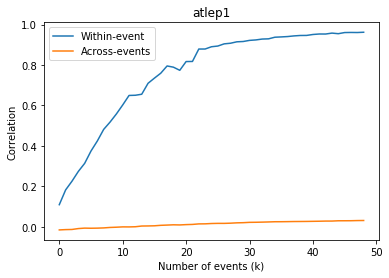

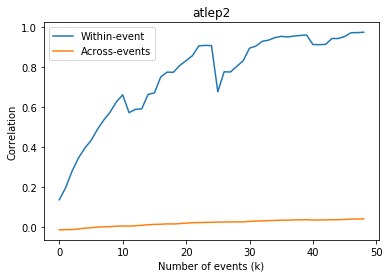

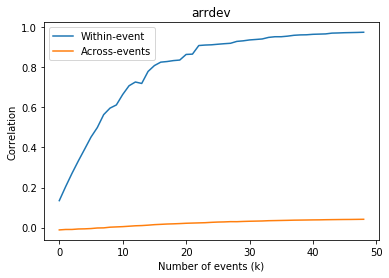

In [10]:
for ep, ks in ep_ks.items():
    plt.plot(list(map(lambda x: x[0], ks)), label='Within-event')
    plt.plot(list(map(lambda x: x[1], ks)), label='Across-events')
    plt.title(ep)
    plt.legend()
    plt.xlabel('Number of events (k)')
    plt.ylabel('Correlation')
    plt.show()

## plot ratio of within- & across-event correlations as a function of k

atlep1: Max ratio at 27 events


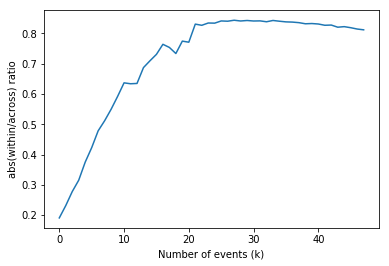

atlep2: Max ratio at 21 events


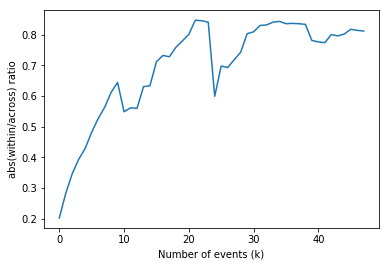

arrdev: Max ratio at 21 events


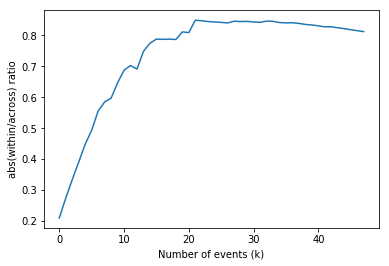

In [15]:
ep_max_ks = []
for ep, ks in ep_ks.items():
#     t=list(map(lambda x: x[0]/(x[1]-min(ks[1])), ks))[1:]
    t=list(map(lambda x: x[0]/(x[1]-ks[1][2]), ks))[1:]
    t/=np.max(t)
    
    for i, v in enumerate(t):
        t[i]-=i/250    # regularization parameter (5 x episode_wsize)
    
    plt.plot(t)
    plt.ylabel('abs(within/across) ratio')
    plt.xlabel('Number of events (k)')
    print(f'{ep}: Max ratio at {np.argmax(t)} events')
    ep_max_ks.append((ep, np.argmax(t)))
    plt.show()

## fit eventseg model with optimal k to each, save eventseg model, save segmented episode model, save onset/offset times for each event (midpoint time of 1st/last annotation in each event)

In [13]:
def reduce_model(m, ev):
    """
    Reduce a model based on event labels
    """
    w = (np.round(ev)==1).astype(bool)
    return np.array([m[wi, :].mean(0) for wi in w.T])

In [16]:
# for ep_name, max_k in ep_max_ks:
#     ev = event.EventSegment(max_k)
#     ev.fit(ep_models_dict[ep_name])
#     episode_events = reduce_model(ep_models_dict[ep_name], ev)
    
#     # save episodes' fit eventseg models
#     with open(pickle_dir+'/eventseg-models/{}_eventseg_model.p'.format(ep_name), 'wb') as f:
#         pickle.dump(ev, f)
    
#     # save segmented episode models
#     np.save(model_dir+'/{}_events'.format(ep_name), episode_events)
    
#     event_onsets_offsets = []
    
#     # get onset/offset times
#     for s in ev.segments_[0].T:
#         tpts = np.where(np.round(s)==1)[0]
#         event_onsets_offsets.append((tpts[0], tpts[-1]))
        
#     # save onset/offset times
#     with open(pickle_dir+'/eventseg-models/{}_event_times.p'.format(ep_name), 'wb') as f:
#         pickle.dump(event_onsets_offsets, f)

## find optimal k for each recall trajecotry (load data from cluster scripts)

In [13]:
participant_max_ks = {'atlep1' : [], 'atlep2' : [], 'arrdev' : [], 'prediction' : [],
                     'delayed' : []}

In [14]:
# bias optimization against large numbers of events
norm_term = 50
# set maximum number of possible events
event_limit = 50

for root, dirs, files in os.walk(rec_model_dir+'/eventseg-models'):
    k_fits = [f for f in files if f.startswith('k') and f.endswith('.npy') and int(f.split('.')[0][1:])<=event_limit]
    if k_fits:
        _, turkid = os.path.split(root)
        rectype = os.path.split(_)[1]
        mcorr = np.corrcoef(next(i for i in participant_models[rectype] if i[0] == turkid)[1])
        cs = []
        for k_fit in k_fits:
            k = int(os.path.splitext(k_fit)[0][1:])
            segments = np.load(os.path.join(root,k_fit))
            i1, i2 = np.where(np.round(segments)==1)
            w = np.zeros_like(segments)
            w[i1,i2] = 1
            w = np.dot(w, w.T).astype(bool)
            c = mcorr[w].mean()/mcorr[~w].mean() - k/norm_term
            cs.append(c)
            
        m = k_fits[np.argmax(cs)]
        participant_max_ks[rectype].append((turkid, m))
        
with open(pickle_dir+'participant_max_ks_50.p', 'wb') as f:
    pickle.dump(participant_max_ks, f)

In [51]:
with open(pickle_dir+'participant_max_ks.p', 'rb') as f:
    participant_max_ks = pickle.load(f)

## use segmented model with optimal k, get onset/offset times, save models

In [52]:
# participant_events = {'atlep1' : [], 'atlep2' : [], 'arrdev' : [], 'delayed': [], 'prediction' : []}

# for rectype, data in participant_max_ks.items():
#     for (turkid, maxk) in data:
        
#         # load in best eventseg model and find corresponding recall trajectory
#         ev = np.load(os.path.join(rec_model_dir, 'eventseg-models', rectype, turkid, maxk))
#         rec_mod = next(i for i in participant_models[rectype] if i[0] == turkid)[1]
        
#         # segment recall trajectory, save
#         recall_events = reduce_model(rec_mod, ev)
#         participant_events[rectype].append((turkid, recall_events))
        
#         # save segmented trajectory
#         np.save(os.path.join(rec_seg_dir, 'k:'+str(norm_term), rectype, turkid+'_events.npy'), recall_events)
        
#         # get event onset/offset times, save
#         event_onsets_offsets = []
#         for s in ev.T:
#             tpts = np.where(np.round(s)==1)[0]
#             event_onsets_offsets.append((tpts[0], tpts[-1]))
#         np.save(os.path.join(rec_seg_dir, 'k:'+str(norm_term), rectype, turkid+'_event_times.npy'), 
#                 event_onsets_offsets)

## load & organize event-segmented models

In [49]:
# load episode events
episode_events = {}
for episode in ['atlep1','atlep2','arrdev']:
    episode_events[episode] = np.load(os.path.join(ep_seg_dir,episode+'_events.npy'))
    
participant_events = {'atlep1' : [], 'atlep2' : [], 'arrdev' : [], 'delayed' : [], 'prediction' : []}
for root, dirs, files in os.walk(os.path.join(rec_seg_dir,'k:'+str(norm_term))):
    indv_events = [f for f in files if f.startswith('debug') and f.endswith('events.npy')]
    if indv_events:
        rectype = os.path.split(root)[1]
        for ev_mod in indv_events:
            participant_events[rectype].append((ev_mod.split('_')[0], np.load(os.path.join(root,ev_mod))))

## create & save average participant event-segmented model for each audio type

In [53]:
participant_opt_eventsegs = {k : [] for k in participant_max_ks.keys()}

for rectype, maxklist in participant_max_ks.items():
    for (turkid, maxk) in maxklist:
        participant_opt_eventsegs[rectype].append(np.load(os.path.join(rec_model_dir, 'eventseg-models', rectype,
                                                                      turkid, maxk)))

In [128]:
for rectype, data in participant_events.items():
    
    # set correct episode trajectory and model
    if rectype == 'delayed':
        ep_events = episode_events['atlep1']
        ep_traj = ep_models_dict['atlep1']corr
    elif rectype == 'prediction':
        ep_events = episode_events['atlep2']
        ep_traj = ep_models_dict['atlep2']
    else:
        ep_events = episode_events[rectype]
        ep_traj = ep_models_dict[rectype]
    
    # match recall events to episode events
    matches = np.array([np.argmax(1 - cdist(ep_events, rec_events, 'correlation'), axis=0) 
                        for (turkid, rec_events) in data])
    
    event_mappings = []
    avg = [[] for i in ep_events]
    for match, (turkid, r_ev) in zip(matches, data):
        event_mappings.append((turkid, match))
        for i, m in enumerate(match):
            avg[m].append(r_ev[i,:])
                        
    # trajectory of average memory for each event. Fill event with 0s if no participant recalled event
    avg_p_events = np.array(list(map(lambda r: np.mean(r,0) if len(r)>0 else np.zeros((100,)), avg)))

    # save average events & event mappings
#     np.save(os.path.join(rec_seg_dir,'k:'+str(norm_term),rectype,'avg_events.npy'), avg_p_events)
#     with open(os.path.join(rec_seg_dir,'k:'+str(norm_term),rectype,'event_mappings.p'), 'wb') as f:
#         pickle.dump(event_mappings, f)

## load & organize average participant event models

In [60]:
avg_participant_events = {rectype : np.load(os.path.join(rec_seg_dir,'k:'+str(norm_term),rectype,'avg_events.npy')) 
                         for rectype in ['atlep1','atlep2','arrdev','delayed','prediction']}